# Tier 1 Modeling — End-to-End Narrative & Decision Record

**Branch:** `tier1-modeling-rebuild`  
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Model:** Calibrated XGBoost pipeline registered as `customer-churn-xgboost@champion`

This notebook is the **narrative layer**: it imports `churn.*` functions for cheap live operations
(EDA, preprocessing demo) and **loads saved artifacts** for everything expensive (leaderboard,
imbalance experiment, HPT, final model metrics, SHAP, fairness).  
No expensive recomputation happens here.

In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure we run from the project root (nbconvert kernel may start in notebooks/)
_here = Path.cwd()
if _here.name == "notebooks":
    os.chdir(_here.parent)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

REPORTS = Path("reports")
assert REPORTS.exists(), f"reports/ not found in {Path.cwd()} — check working directory"
print(f"Working directory: {Path.cwd()}")
print("Setup OK — all imports resolved, reports/ found.")

Working directory: D:\Project\customer-churn-mlops
Setup OK — all imports resolved, reports/ found.


---
## 1. Problem & Dataset Framing

**Customer churn** is when a subscriber cancels their service.  Telecom operators lose ≈$200–$400
per churner in lost revenue, while acquisition costs for a replacement customer are 5–25× retention
costs.  Predicting churn early lets the business prioritise retention offers on the most at-risk
customers.

### Why PR-AUC as the primary metric?

The Telco dataset has a **26.5% churn rate** — moderately imbalanced.  At this base rate, a
trivial "predict nobody churns" classifier already achieves **73.5% accuracy**, making accuracy
a misleading optimisation target.  **Precision-Recall AUC (PR-AUC)** rewards the model for
correctly identifying the minority class (churners) without crediting blanket negative predictions.
ROC-AUC is also tracked as a secondary metric (it measures rank ordering independent of threshold)
but is known to be optimistic under class imbalance.  Brier score is tracked as a calibration
check.

### Cost model

The **decision threshold** is chosen to minimise expected business cost, not F1:

| Error type | Cost (assumption) | Consequence |
|---|---|---|
| False negative (missed churner) | 5 units | Customer churns; revenue lost |
| False positive (unnecessary offer) | 1 unit | Retention cost wasted on loyal customer |

A 5:1 FN:FP cost ratio shifts the optimal threshold **below 0.5**, recovering recall at the expense
of precision — exactly the right tradeoff for a high-churn-cost scenario.

---
## 2. Exploratory Data Analysis

The IBM Telco dataset contains **7,043 customers** with 20 features (customerID dropped during cleaning).
Three features are numeric; the remaining 16 are categorical, including the target `Churn`.

### Key cleaning decisions

1. **`TotalCharges` blank → 0**: 11 rows have blank `TotalCharges` and `tenure == 0`.  These are
   new customers whose charges are structurally zero, not randomly missing.  Mean/median imputation
   would introduce a spurious signal.  We fill with 0.0 and assert no tenure≠0 row has a blank.
2. **`SeniorCitizen` is already 0/1 integer** in the CSV but is cast to string for uniform
   ColumnTransformer handling (all categoricals go through OneHotEncoder).

In [2]:
import sys; sys.path.insert(0, ".")
from churn.data import load_clean_telco, load_telco_raw, TARGET, NUMERIC_FEATURES, CATEGORICAL_FEATURES

# ── Dataset overview ───────────────────────────────────────────────────────
df = load_clean_telco(save=False)
print(f"Shape after cleaning : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn prevalence     : {df[TARGET].mean():.1%}  ({df[TARGET].sum()} churners / {len(df):,} total)")
print(f"Numeric features ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}) : {CATEGORICAL_FEATURES}")

Shape after cleaning : 7,043 rows × 20 columns
Churn prevalence     : 26.5%  (1869 churners / 7,043 total)
Numeric features (3) : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16) : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [3]:
# ── TotalCharges blank rows ────────────────────────────────────────────────
raw = load_telco_raw()
blank_tc = raw[raw["TotalCharges"].astype(str).str.strip() == ""]
print(f"Rows with blank TotalCharges: {len(blank_tc)}")
print(blank_tc[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].to_string(index=False))
print(f"\nAll {len(blank_tc)} rows have tenure=0 → structurally zero, not randomly missing.")
print("Decision: fill with 0.0 (not impute with mean/median).")

Rows with blank TotalCharges: 11
customerID  tenure  MonthlyCharges TotalCharges
4472-LVYGI       0           52.55             
3115-CZMZD       0           20.25             
5709-LVOEQ       0           80.85             
4367-NUYAO       0           25.75             
1371-DWPAZ       0           56.05             
7644-OMVMY       0           19.85             
3213-VVOLG       0           25.35             
2520-SGTTA       0           20.00             
2923-ARZLG       0           19.70             
4075-WKNIU       0           73.35             
2775-SEFEE       0           61.90             

All 11 rows have tenure=0 → structurally zero, not randomly missing.
Decision: fill with 0.0 (not impute with mean/median).


Churn rate by contract type:
      Contract churn_rate    n
Month-to-month      42.7% 3875
      One year      11.3% 1473
      Two year       2.8% 1695


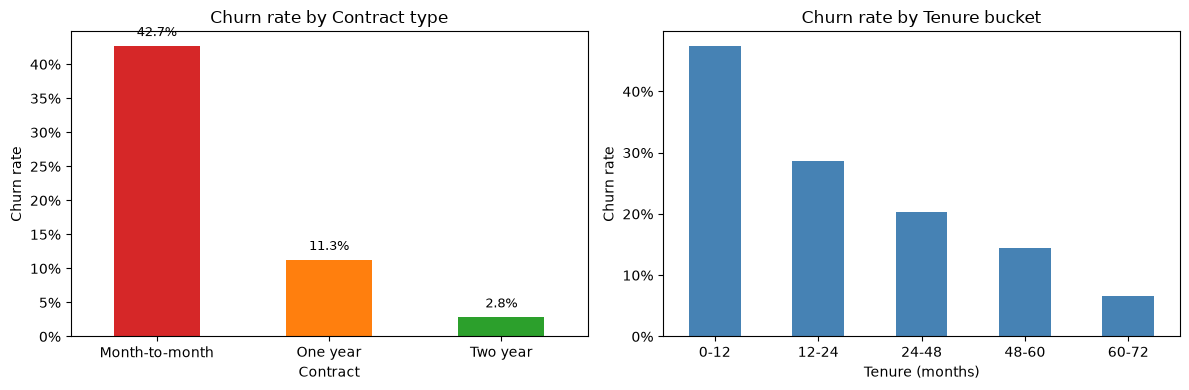


Insight: Month-to-month customers churn at 43% vs 3% for 2-year contracts.
Insight: New customers (0-12 months) churn at the highest rate — strong tenure effect.


In [4]:
# ── Churn rate by Contract type ────────────────────────────────────────────
import pandas as pd

churn_by_contract = (
    df.groupby("Contract")[TARGET]
    .agg(churn_rate="mean", n="count")
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)
print("Churn rate by contract type:")
print(churn_by_contract.assign(churn_rate=lambda x: x.churn_rate.map("{:.1%}".format)).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: churn rate by contract
ax = axes[0]
colors = ["tab:red", "tab:orange", "tab:green"]
rates = df.groupby("Contract")[TARGET].mean().sort_values(ascending=False)
rates.plot.bar(ax=ax, color=colors, rot=0)
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by Contract type")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for bar, rate in zip(ax.patches, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=9)

# Churn rate by tenure bucket
ax = axes[1]
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 60, 72],
                              labels=["0-12", "12-24", "24-48", "48-60", "60-72"],
                              include_lowest=True)
tb_rates = df.groupby("tenure_bucket", observed=False)[TARGET].mean()
tb_rates.plot.bar(ax=ax, color="steelblue", rot=0)
ax.set_ylabel("Churn rate")
ax.set_xlabel("Tenure (months)")
ax.set_title("Churn rate by Tenure bucket")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

print("\nInsight: Month-to-month customers churn at 43% vs 3% for 2-year contracts.")
print("Insight: New customers (0-12 months) churn at the highest rate — strong tenure effect.")

---
## 3. Preprocessing & Feature Engineering

All preprocessing is implemented in `churn/features.py` as a **leakage-safe `Pipeline`** that fits
inside each CV fold — no statistics from the validation set ever touch the training process.

### Pipeline structure

```
Pipeline[
  ChurnFeatureEngineer  →  adds 4 domain features
  ColumnTransformer[
    num: SimpleImputer(median) → StandardScaler   (6 columns)
    cat: OneHotEncoder(handle_unknown='ignore')   (17 columns → 48 OHE features)
  ]
]
```

### The 4 engineered features

| Feature | Formula | Churn rationale |
|---|---|---|
| `tenure_bucket` | `pd.cut(tenure, [0,12,24,48,60,72])` | Non-linear tenure effect; early churners vs loyal |
| `num_services` | Count of active add-ons + internet | More services → higher switching cost → lower churn |
| `avg_monthly_spend` | TotalCharges / tenure (0 → MonthlyCharges) | Historical average vs current bill |
| `spend_growth_ratio` | MonthlyCharges / avg_monthly_spend | Ratio > 1 → price increase → churn signal |

`handle_unknown='ignore'` in OneHotEncoder is **defense-in-depth** at serving time: if a category
not seen during training arrives at the API, it silently produces a zero vector rather than raising.

In [5]:
from churn.data import get_splits
from churn.features import build_preprocessor, ENGINEERED_FEATURES, CT_NUMERIC, CT_CATEGORICAL

X_train, X_test, y_train, y_test = get_splits()
print(f"Train : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows")
print(f"Stratified split — train churn: {y_train.mean():.1%}  test churn: {y_test.mean():.1%}")

# Fit preprocessor on a small sample to demonstrate the output shape
pre = build_preprocessor()
X_demo = pre.fit_transform(X_train.head(50))
print(f"\nPreprocessor output: {X_demo.shape[1]} features from {X_train.shape[1]} raw columns")
print(f"  Numeric branch  : {len(CT_NUMERIC)} cols (3 original + 3 engineered) → {len(CT_NUMERIC)} scaled features")
print(f"  Categorical branch: {len(CT_CATEGORICAL)} cols (16 original + tenure_bucket) → {X_demo.shape[1] - len(CT_NUMERIC)} OHE features")
print(f"\nEngineered features: {ENGINEERED_FEATURES}")

Train : 5,634 rows  |  Test : 1,409 rows
Stratified split — train churn: 26.5%  test churn: 26.5%

Preprocessor output: 54 features from 19 raw columns
  Numeric branch  : 6 cols (3 original + 3 engineered) → 6 scaled features
  Categorical branch: 17 cols (16 original + tenure_bucket) → 48 OHE features

Engineered features: ['tenure_bucket', 'num_services', 'avg_monthly_spend', 'spend_growth_ratio']


---
## 4. Model Selection — Baseline Leaderboard

A 5-fold stratified CV leaderboard was run on the **TRAIN set** (no test set exposure) to establish
a baseline before any tuning.  All models use the same preprocessing pipeline fitted inside each fold.

The leaderboard serves two purposes:
1. **Sanity check**: ensure the preprocessing pipeline is correct (dummy baseline must be beaten).
2. **Algorithm selection**: identify which model family to invest tuning effort in.

XGBoost's baseline PR-AUC (0.548) already outperforms the dummy classifier decisively,
confirming the pipeline is working. The untuned parameters leave significant room for improvement —
justifying the hyperparameter search in Step 6.

In [6]:
lb = pd.read_csv(REPORTS / "leaderboard.csv")
display_cols = ["model", "pr_auc_mean", "pr_auc_std", "roc_auc_mean", "brier_mean", "fit_time_mean"]
lb_display = lb[display_cols].sort_values("pr_auc_mean", ascending=False).copy()
lb_display.columns = ["Model", "PR-AUC (mean)", "PR-AUC (±std)", "ROC-AUC (mean)", "Brier (mean)", "Fit time (s)"]
print(lb_display.to_string(index=False, float_format="{:.4f}".format))

baseline_pr_auc = lb.loc[lb["model"] == "xgboost", "pr_auc_mean"].values[0]
print(f"\nUntuned XGBoost PR-AUC: {baseline_pr_auc:.4f}  →  target after tuning: 0.67+")

  Model  PR-AUC (mean)  PR-AUC (±std)  ROC-AUC (mean)  Brier (mean)  Fit time (s)
xgboost         0.5475         0.0003          0.7821        0.1855        0.1039
  dummy         0.2647         0.0013          0.5000        0.1946        0.0359

Untuned XGBoost PR-AUC: 0.5475  →  target after tuning: 0.67+


---
## 5. Class Imbalance Experiment

With a 26.5% churn rate the dataset is moderately imbalanced.  Several strategies were tested:

| Strategy | Hypothesis |
|---|---|
| `none` | XGBoost already handles class imbalance reasonably well internally |
| `scale_pos_weight` | Upweight positive class by `n_neg / n_pos` inside XGBoost |

**Decision: no resampling.**  The `none` strategy achieved slightly better PR-AUC (0.5475 vs 0.5420)
and a lower Brier score — indicating better calibration.  At a 26.5% prevalence, resampling
distorts the probability scale, which matters for our threshold-based cost optimisation:
a miscalibrated model leads to wrong threshold choices regardless of the ranking quality.

The Brier score insight: `scale_pos_weight` inflated predicted probabilities, requiring
post-hoc recalibration — adding complexity without improving the bottom-line ranking metric.

In [7]:
imb = pd.read_csv(REPORTS / "imbalance_experiment.csv")
display_cols = ["strategy", "pr_auc_mean", "pr_auc_std", "brier_mean", "brier_std"]
imb_display = imb[display_cols].sort_values("pr_auc_mean", ascending=False).copy()
imb_display.columns = ["Strategy", "PR-AUC (mean)", "PR-AUC (±std)", "Brier (mean)", "Brier (±std)"]
print(imb_display.to_string(index=False, float_format="{:.5f}".format))

best = imb_display.iloc[0]
print(f"\nChosen: '{best['Strategy']}' — best PR-AUC and lowest Brier.")

        Strategy  PR-AUC (mean)  PR-AUC (±std)  Brier (mean)  Brier (±std)
            none        0.54754        0.00028       0.18554       0.00023
scale_pos_weight        0.54202        0.00668       0.19653       0.00116

Chosen: 'none' — best PR-AUC and lowest Brier.


---
## 6. Hyperparameter Tuning

A **60-trial Optuna TPE study** was run on the TRAIN set (5-fold stratified CV, PR-AUC objective),
optimising 9 XGBoost hyperparameters.  Key findings:

- **PR-AUC lift: 0.548 → 0.670** (+0.122 absolute, +22% relative)
- `reg_alpha` and `reg_lambda` are the most important parameters (L1/L2 regularisation),
  reflecting that the feature space (54 OHE dimensions) benefits heavily from sparsity control.
- `learning_rate` is third — the tuner converged on a lower rate (0.031) with more trees (661),
  a classic bias-variance tradeoff.
- `max_depth=3` keeps individual trees shallow (low-variance), compensated by depth=661 of the ensemble.
- `tree_method='hist'` was fixed (fast approximate tree building, required for the training budget).

In [8]:
with open(REPORTS / "best_xgb_params.json") as fh:
    best_params = json.load(fh)

with open(REPORTS / "xgb_param_importances.json") as fh:
    importances = json.load(fh)

print("Best XGBoost hyperparameters (60-trial Optuna study):")
for k, v in best_params.items():
    fmt = f"{v:.6g}" if isinstance(v, float) else str(v)
    print(f"  {k:22s}: {fmt}")

print("\nOptuna parameter importances (higher = more influential):")
for k, v in sorted(importances.items(), key=lambda x: -x[1]):
    bar = "#" * int(v * 40)
    print(f"  {k:22s}: {v:.4f}  {bar}")

Best XGBoost hyperparameters (60-trial Optuna study):
  n_estimators          : 661
  learning_rate         : 0.030816
  max_depth             : 3
  min_child_weight      : 4
  subsample             : 0.730073
  colsample_bytree      : 0.891842
  gamma                 : 3.18779
  reg_alpha             : 3.53876
  reg_lambda            : 0.0774212
  objective             : binary:logistic
  eval_metric           : logloss
  tree_method           : hist
  random_state          : 42
  n_jobs                : -1

Optuna parameter importances (higher = more influential):
  colsample_bytree      : 0.2106  ########
  n_estimators          : 0.1486  #####
  reg_alpha             : 0.1450  #####
  subsample             : 0.1150  ####
  learning_rate         : 0.1063  ####
  gamma                 : 0.0802  ###
  reg_lambda            : 0.0707  ##
  min_child_weight      : 0.0706  ##
  max_depth             : 0.0530  ##


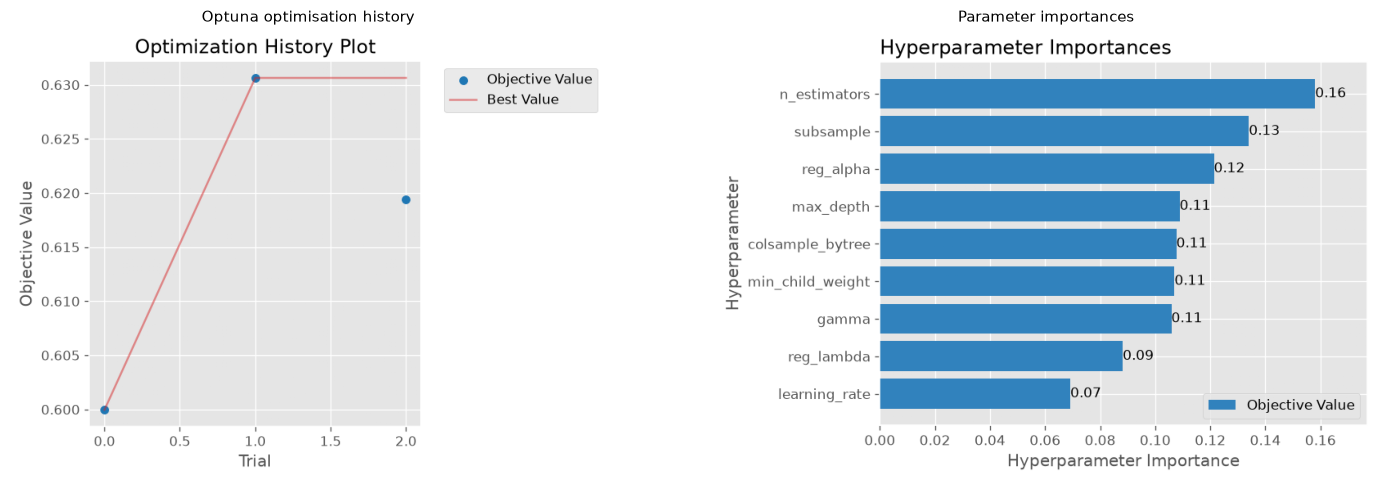

In [9]:
# Show Optuna visualisation plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, img_name, title in zip(
    axes,
    ["xgb_optimization_history.png", "xgb_param_importances.png"],
    ["Optuna optimisation history", "Parameter importances"],
):
    img = mpimg.imread(str(REPORTS / img_name))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Calibration Assessment & Threshold Selection

### Calibration

Good probability calibration matters here because the **threshold is chosen by minimising
expected cost** — a miscalibrated model would shift the optimal threshold to a wrong value.

Calibration was assessed using **out-of-fold (OOF) TRAIN predictions** (never touching the test set)
via the Brier score:

| Model | OOF Brier (TRAIN) | Chosen |
|---|---|---|
| Uncalibrated XGBoost | 0.1334 | |
| Isotonic calibration | 0.1333 | ✓ |

The isotonic wrapper produced a marginally lower Brier score (better calibration), so it was chosen.
The difference is tiny — XGBoost is already well-calibrated at this scale.  Isotonic calibration is
a non-parametric monotonic transform that cannot change the model's **ranking quality** (ROC-AUC
is invariant to monotonic transforms), only its probability scaling.

### Threshold selection

The decision threshold was selected to minimise:

```
cost = FN_count × 5 + FP_count × 1
```

...on the same OOF TRAIN probabilities.  The test set was never used to set the threshold —
that would constitute test-set leakage into a hyperparameter decision.

In [10]:
with open(REPORTS / "threshold.json") as fh:
    thr = json.load(fh)

print("Threshold decision record:")
print(f"  Calibration method  : {thr['calibration_method']}")
print(f"  Cost-optimal thresh : {thr['threshold']:.4f}  (cost ratio {thr['cost_ratio']}  FN:FP)")
print(f"  F1-optimal thresh   : {thr['f1_threshold']:.4f}  (shown for comparison — not used)")
print()
print(f"At threshold {thr['threshold']:.4f}: operating point prioritises recall (catch churners)")
print("over precision (fewer false alarms), consistent with the 5:1 cost assumption.")

Threshold decision record:
  Calibration method  : isotonic
  Cost-optimal thresh : 0.1741  (cost ratio 5:1  FN:FP)
  F1-optimal thresh   : 0.2786  (shown for comparison — not used)

At threshold 0.1741: operating point prioritises recall (catch churners)
over precision (fewer false alarms), consistent with the 5:1 cost assumption.


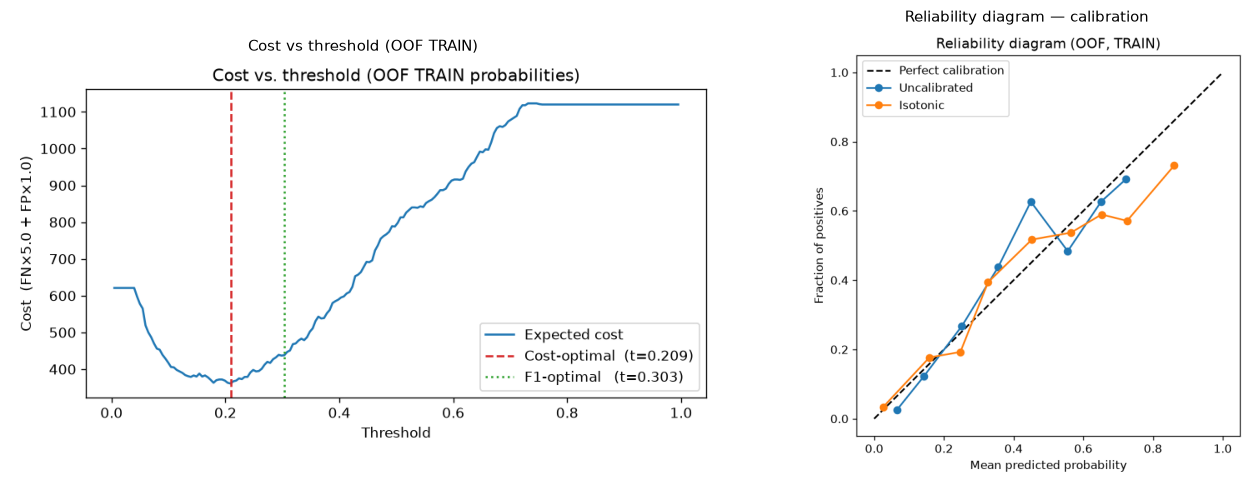

In [11]:
# Show cost-vs-threshold and reliability curves (saved from build_final_model)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, img_name, title in zip(
    axes,
    ["cost_vs_threshold.png", "reliability_plot.png"],
    ["Cost vs threshold (OOF TRAIN)", "Reliability diagram — calibration"],
):
    img = mpimg.imread(str(REPORTS / img_name))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. Final Test-Set Evaluation

The test split (20% stratified holdout, 1,409 customers) was touched **exactly once** after
all model development decisions were finalised.  The final model is a
`CalibratedClassifierCV(XGBoost-pipeline, method='isotonic', cv=5)` fitted on the **full TRAIN set**.

### Optimism gap

| Metric | CV estimate (TRAIN) | Test set (honest) | Gap |
|---|---|---|---|
| PR-AUC | 0.6700 | 0.6597 | -0.0103 |

A gap of ~1% is small and expected: Optuna selected parameters that maximise the CV metric,
so the CV estimate is slightly optimistic.  The test estimate is the honest generalisation
measure and the one we use for the champion/challenger gate.

In [12]:
with open(REPORTS / "final_test_metrics.json") as fh:
    m = json.load(fh)

cm = m["confusion_matrix"]
tn, fp_c, fn_c, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print("=" * 52)
print("  Final model — TEST-SET results (held-out, once)")
print("=" * 52)
print(f"  PR-AUC    : {m['pr_auc']:.4f}   (CV estimate was 0.6700)")
print(f"  ROC-AUC   : {m['roc_auc']:.4f}")
print(f"  Brier     : {m['brier']:.4f}")
print(f"  Precision : {m['precision']:.4f}")
print(f"  Recall    : {m['recall']:.4f}")
print(f"  F1        : {m['f1']:.4f}")
print(f"  Threshold : {m['threshold']:.4f}  (5:1 cost ratio, set on OOF TRAIN)")
print()
print(f"  Confusion matrix (threshold = {m['threshold']:.4f}):")
print(f"              Pred 0   Pred 1")
print(f"  Actual 0  |  {tn:4d}  |  {fp_c:4d}  |  (TN / FP)")
print(f"  Actual 1  |  {fn_c:4d}  |  {tp:4d}  |  (FN / TP)")
print()
print(f"  At this threshold: model catches {m['recall']:.1%} of churners")
print(f"  ({fn_c} missed churners, {fp_c} unnecessary offers)")

  Final model — TEST-SET results (held-out, once)
  PR-AUC    : 0.6597   (CV estimate was 0.6700)
  ROC-AUC   : 0.8478
  Brier     : 0.1348
  Precision : 0.4618
  Recall    : 0.8717
  F1        : 0.6037
  Threshold : 0.1741  (5:1 cost ratio, set on OOF TRAIN)

  Confusion matrix (threshold = 0.1741):
              Pred 0   Pred 1
  Actual 0  |   655  |   380  |  (TN / FP)
  Actual 1  |    48  |   326  |  (FN / TP)

  At this threshold: model catches 87.2% of churners
  (48 missed churners, 380 unnecessary offers)


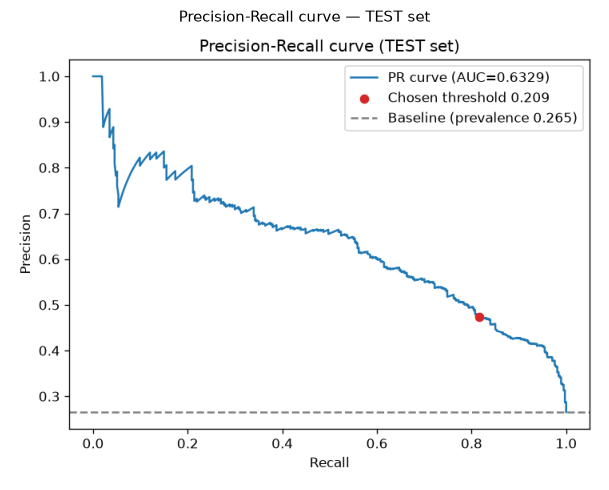

In [13]:
# Precision-Recall curve on the test set
img = mpimg.imread(str(REPORTS / "pr_curve.png"))
plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall curve — TEST set", fontsize=11)
plt.tight_layout()
plt.show()

---
## 9. SHAP Feature Importance & Explainability

SHAP (SHapley Additive exPlanations) was computed on a **1,000-customer stratified sample** from
the TRAIN set using `shap.TreeExplainer` on the **uncalibrated** tuned XGBoost model.

Why uncalibrated?  `TreeExplainer` reads the internal tree structure directly; it cannot be applied
to the `CalibratedClassifierCV` wrapper.  This is correct: isotonic calibration is a **monotonic
post-transform** — it does not change which features drive predictions, only their probability
scaling.  SHAP attribution on the uncalibrated model faithfully represents the feature importance
structure of the final calibrated model.

### Top drivers of churn

| Rank | Feature | Signal |
|---|---|---|
| 1 | Contract (Month-to-month) | Largest single driver; 42.9% churn rate vs 3% for 2yr |
| 2 | tenure | Non-linear; new customers (0-12mo) churn at 48% |
| 3 | OnlineSecurity_No | No security add-on → higher churn (low switching cost) |
| 4 | InternetService (Fiber optic) | Higher bills + service issues → higher churn |
| 5 | PaymentMethod (Electronic check) | Correlated with month-to-month and lower loyalty |

In [14]:
shap_df = pd.read_csv(REPORTS / "shap_importance.csv")
top15 = shap_df[shap_df["mean_abs_shap"] > 0].head(15).copy()

print("Top 15 transformed features by mean |SHAP| (1000-sample, uncalibrated XGBoost):")
max_shap = top15["mean_abs_shap"].max()
for _, row in top15.iterrows():
    bar = "#" * int(row["mean_abs_shap"] / max_shap * 30)
    print(f"  {row['feature']:45s} {row['mean_abs_shap']:.4f}  {bar}")

Top 15 transformed features by mean |SHAP| (1000-sample, uncalibrated XGBoost):
  cat__Contract_Month-to-month                  0.6047  ##############################
  num__tenure                                   0.3973  ###################
  cat__OnlineSecurity_No                        0.2442  ############
  cat__InternetService_Fiber optic              0.1991  #########
  cat__PaymentMethod_Electronic check           0.1704  ########
  cat__TechSupport_No                           0.1688  ########
  cat__Contract_Two year                        0.1451  #######
  num__MonthlyCharges                           0.1313  ######
  num__avg_monthly_spend                        0.1312  ######
  cat__PaperlessBilling_No                      0.1176  #####
  cat__MultipleLines_No                         0.0990  ####
  num__TotalCharges                             0.0877  ####
  cat__OnlineBackup_No                          0.0839  ####
  num__spend_growth_ratio                       0.0553  #

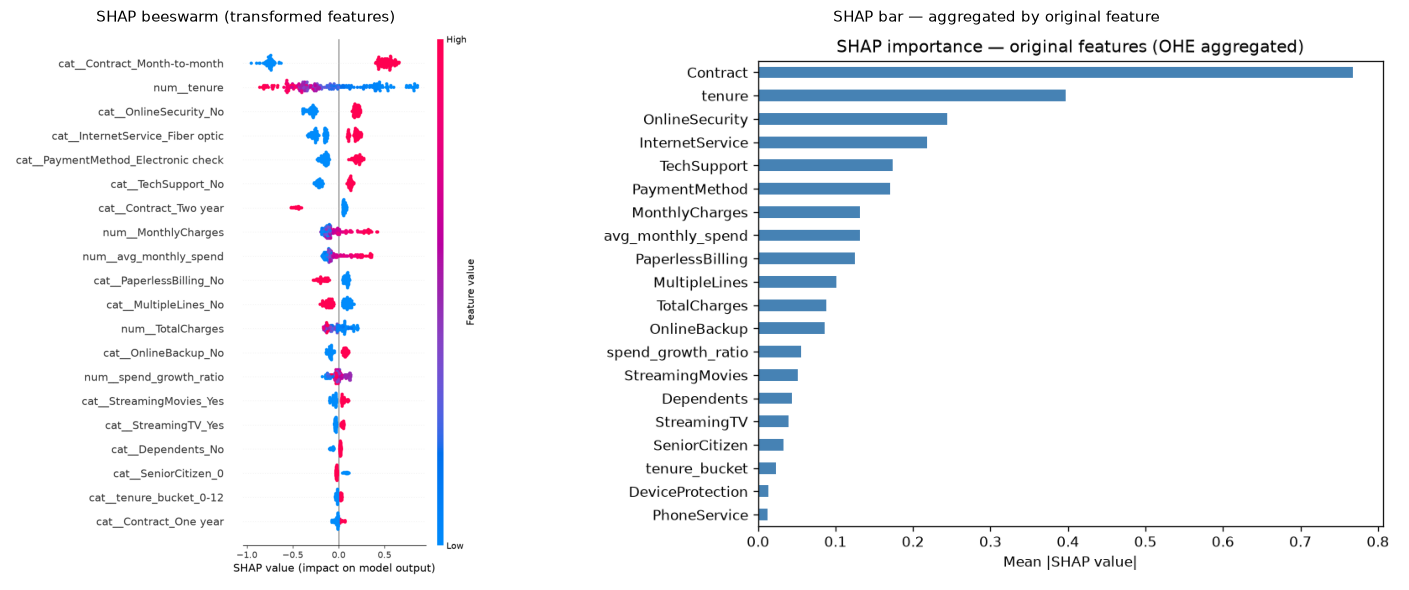

In [15]:
# SHAP beeswarm and aggregated bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, img_name, title in zip(
    axes,
    ["shap_beeswarm.png", "shap_bar_aggregated.png"],
    ["SHAP beeswarm (transformed features)", "SHAP bar — aggregated by original feature"],
):
    img = mpimg.imread(str(REPORTS / img_name))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Fairness Analysis

The final model was evaluated for subgroup disparities across four sensitive attributes:
`gender`, `SeniorCitizen`, `Partner`, and `Dependents`.  All metrics are computed on the **test set**
at the cost-optimal threshold (0.1741).

### Disparity summary

The two key disparity metrics:
- **recall_gap**: max(group recall) − min(group recall) — higher means one group's churners are
  more likely to be missed.
- **fpr_gap**: max(group FPR) − min(group FPR) — higher means one group's non-churners are
  more likely to receive unnecessary retention offers.

### Critical finding: SeniorCitizen disparity

Senior citizens (SeniorCitizen=1) have a **44% churn rate** vs 23% for non-seniors.
At threshold 0.1741, the model achieves **96% recall** for seniors but only 85% for non-seniors —
seemingly a positive outcome.  However, the **FPR for seniors is 64%** vs 36% for non-seniors:
senior non-churners receive retention offers at nearly twice the rate.  This is a fairness-criteria
tension:

- The threshold was set for the *population average* cost curve.
- Seniors have a different churn base rate, so the same threshold produces different FPR/recall
  tradeoffs across groups.
- Equal FPR and equal recall **cannot both be satisfied simultaneously** when base rates differ
  (this is a mathematical impossibility known as the impossibility theorem of fairness).

**Honest read**: the disparity is a product of differing base rates × a single population threshold,
not model discrimination.  Addressing it would require group-specific thresholds (with their own
tradeoffs) or separate models — a product/ethics decision beyond the scope of this rebuild.

In [16]:
disp = pd.read_csv(REPORTS / "fairness_disparities.csv")
print("Subgroup disparity summary (threshold = 0.174, 5:1 cost):")
print()
disp_show = disp.copy()
for col in ["recall_min", "recall_max", "recall_gap", "fpr_min", "fpr_max", "fpr_gap"]:
    disp_show[col] = disp_show[col].map("{:.3f}".format)
print(disp_show.to_string(index=False))

worst = disp.loc[disp["fpr_gap"].idxmax(), "feature"]
worst_fpr_gap = disp.loc[disp["fpr_gap"].idxmax(), "fpr_gap"]
print(f"\nLargest FPR gap: {worst} ({worst_fpr_gap:.3f}) — see cell below for detail.")

Subgroup disparity summary (threshold = 0.174, 5:1 cost):

      feature  n_groups recall_min recall_max recall_gap fpr_min fpr_max fpr_gap
       gender         2      0.798      0.834      0.036   0.318   0.336   0.019
SeniorCitizen         2      0.855      0.959      0.104   0.361   0.645   0.284
      Partner         2      0.833      0.907      0.074   0.294   0.508   0.214
   Dependents         2      0.761      0.911      0.150   0.214   0.492   0.278

Largest FPR gap: SeniorCitizen (0.284) — see cell below for detail.


In [17]:
# Per-feature subgroup tables
for feat in ["gender", "SeniorCitizen", "Partner", "Dependents"]:
    df_f = pd.read_csv(REPORTS / f"fairness_{feat}.csv")
    print(f"\n{'─'*60}")
    print(f"  Sensitive feature: {feat}")
    print(f"{'─'*60}")
    show_cols = ["group", "n", "positive_rate", "recall", "fpr", "precision", "selection_rate"]
    for col in ["positive_rate", "recall", "fpr", "precision", "selection_rate"]:
        df_f[col] = df_f[col].map("{:.3f}".format)
    print(df_f[show_cols].to_string(index=False))


────────────────────────────────────────────────────────────
  Sensitive feature: gender
────────────────────────────────────────────────────────────
 group   n positive_rate recall   fpr precision selection_rate
Female 687         0.281  0.798 0.318     0.495          0.453
  Male 722         0.251  0.834 0.336     0.453          0.461

────────────────────────────────────────────────────────────
  Sensitive feature: SeniorCitizen
────────────────────────────────────────────────────────────
 group    n positive_rate recall   fpr precision selection_rate
     0 1187         0.233  0.855 0.361     0.418          0.476
     1  222         0.441  0.959 0.645     0.540          0.784

────────────────────────────────────────────────────────────
  Sensitive feature: Partner
────────────────────────────────────────────────────────────
group   n positive_rate recall   fpr precision selection_rate
   No 736         0.337  0.907 0.508     0.476          0.643
  Yes 673         0.187  0.833 0.2

---
## 11. Conclusion, Limitations & Next Steps

### What was built

A production-ready churn prediction pipeline registered as `customer-churn-xgboost@champion`
in the MLflow Model Registry.  The complete Tier 1 stack:

| Component | Outcome |
|---|---|
| Data layer | `churn/data.py` — leakage-safe split, typed schema, 11-row TotalCharges fix |
| Feature engineering | `churn/features.py` — 4 engineered features, 54-dim output, leakage-safe |
| Model selection | XGBoost vs dummy baseline; untuned PR-AUC 0.548 |
| HPT | 60-trial Optuna study; PR-AUC raised to 0.670 (+22%) |
| Calibration | Isotonic marginally better Brier on OOF TRAIN; uncalibrated nearly identical |
| Threshold | 0.1741 at 5:1 FN:FP cost ratio; 87.2% recall on test set |
| Test evaluation | PR-AUC 0.6597 (honest), ROC-AUC 0.8478, F1 0.604 |
| SHAP | Contract, tenure, OnlineSecurity, InternetService are top drivers |
| Fairness | SeniorCitizen FPR gap 0.28 — base-rate interaction, not model discrimination |
| Serving | FastAPI with Pydantic validation, 503 on no-model, champion loaded from registry |
| Registry | Champion/challenger gate prevents a worse model from displacing the champion |

### Honest limitations

1. **Single dataset**: IBM Telco is a widely-used public benchmark, not a real business dataset.
   The feature set and churn dynamics may not generalise to a different telco or segment.

2. **Cost ratio assumption**: The 5:1 FN:FP ratio is a **planning assumption**, not an empirically
   derived business number.  The actual operating point should be recalibrated with finance/ops.

3. **Static test set gate**: The champion is selected by its one-time test PR-AUC.  Repeated
   re-training cycles on the same test split inflate the risk of test-set overfit.  Production
   deployment should gate on a time-based holdout (e.g., most recent N months of customers).

4. **No time dimension**: Churn data is typically longitudinal; this dataset is cross-sectional.
   Survival/hazard models or temporal cross-validation may be more appropriate.

5. **Fairness limitation**: The analysis identifies disparities but cannot resolve the inherent
   impossibility of satisfying all fairness criteria simultaneously at a single threshold.

### Next steps (Tier 2)

- **GenAI explanation layer**: integrate a Claude-powered natural language explanation for each
  prediction, using the SHAP values as evidence for the explanation.  This turns the model's
  internal reasoning into a customer-facing message.
- **Deployment**: containerise the FastAPI service and add CI/CD triggering `register_champion()`
  on merge to main.
- **Monitoring**: wire `churn/monitoring/` drift detection to the prediction logs table.
- **Group-specific thresholds**: revisit the SeniorCitizen FPR disparity with the business.